# Extension points: custom schedules, constraints, and calendar events

A dairy buyer orders on **Mondays and Thursdays** for next-day delivery. Cases
come in fixed packs, the chiller has limited space, one Thursday is a supplier
holiday, and a stock count finds missing milk.

None of these needs a change to the engine. Each is an extension point:

| Need | Extension point |
|---|---|
| Order days that are not a fixed interval | subclass `DecisionSchedule` |
| Whole cases that must fit the chiller | subclass `OrderingConstraint` |
| Holiday and stock-count events on known dates | built-in `ScheduledOrderHold`, `ScheduledInventoryAdjustment` |
| Different targets at each order day | `policy_schedule` snapshots of `ReorderPointPolicy` |

Notebook 05 covers custom policies; Notebook 08 covers custom callbacks.

In [2]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast import (
    ConstraintResult, DecisionSchedule, InventoryStateDataFrame, OrderDecision,
    OrderingConstraint, OrderingConstraints, OrderMultiple, ReorderPointPolicy,
    ScheduledInventoryAdjustment, ScheduledOrderHold, ShelfSpaceLimit, SimulationEngine,
)
from stockcast.evaluation import (
    CoverageMetric, InventoryEvaluator, backlog_unit_periods, capacity_violation_count,
    fill_rate, validate_event_frame,
)


def poisson_quantile(probability, mean):
    """Smallest k with P(Poisson(mean) <= k) >= probability."""
    k, pmf = 0, math.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return k

## 1. A custom decision schedule

A schedule answers two questions, using zero-based demand periods:
`should_decide(t)` and `next_decision_period(t)`. It must be deterministic and
must not look at demand. Here demand period 0 is Monday 2 March 2026.

In [3]:
@dataclass(frozen=True)
class WeekdaySchedule(DecisionSchedule):
    """Decide on fixed weekdays (Monday = 0), counted from the first demand date."""

    weekdays: tuple
    first_demand_date: pd.Timestamp

    def should_decide(self, period):
        return (self.first_demand_date + pd.Timedelta(days=period)).weekday() in self.weekdays

    def next_decision_period(self, period):
        return next(p for p in range(period + 1, period + 8) if self.should_decide(p))

    def to_manifest(self):
        return {
            "type": "weekday",
            "weekdays": list(self.weekdays),
            "first_demand_date": self.first_demand_date.isoformat(),
        }


origin = pd.Timestamp("2026-03-01")          # opening state, Sunday
schedule = WeekdaySchedule((0, 3), origin + pd.Timedelta(days=1))  # Mon, Thu
[p for p in range(14) if schedule.should_decide(p)]

[0, 3, 7, 10]

## 2. The scenario

Three SKUs with Poisson daily demand at known rates, so differences come from
operations rather than forecast error. Lead time is 1 day. Unmet demand is
**backordered**. We warm up for one week, score three weeks, and settle one
week without new orders.

In [4]:
skus = ["milk", "yogurt", "cheese"]
rate = {"milk": 14.0, "yogurt": 6.0, "cheese": 2.5}          # units per day
pack = {"milk": 12.0, "yogurt": 8.0, "cheese": 6.0}           # units per case
space = {"milk": 108.0, "yogurt": 60.0, "cheese": 30.0}       # chiller units
lead, alpha, seed = 1, 0.95, 3
warmup, scoring, settlement = 7, 21, 7
n_periods = warmup + scoring + settlement

rng = np.random.default_rng(seed)
y = np.column_stack([rng.poisson(rate[sku], n_periods) for sku in skus]).astype(float)
demand = pd.DataFrame({
    "unique_id": np.tile(skus, n_periods),
    "period": np.repeat(np.arange(n_periods), len(skus)),
    "date": np.repeat(pd.date_range(origin + pd.Timedelta(days=1), periods=n_periods), len(skus)),
    "y": y.reshape(-1),
})


def opening_inventory():
    return InventoryStateDataFrame(
        skus, max_lead_time=lead, allow_backorders=True,
    ).initialize_from_observed(
        pd.DataFrame({"unique_id": skus, "stock": [40.0, 20.0, 10.0]}),
        on_hand_column="stock", start_date=origin,
    )

## 3. Irregular windows need one target per order day

If the buyer does not order on day `t`, the next order is placed at the next
opportunity `u` and arrives before demand `u + L`. The reorder point must
therefore cover `H = (u − t) + L` days:

- Monday → Thursday: `H = 3 + 1 = 4` days;
- Thursday → Monday: `H = 4 + 1 = 5` days.

Each order day gets its own fitted `ReorderPointPolicy` snapshot, dated at that
day's information cutoff. `s` is the 95% Poisson quantile over `H`. `S` adds two
days of mean demand as cycle stock; it is a policy level, not a quantile. The
engine checks every snapshot's window against the schedule before the run.

In [5]:
decision_periods = [
    p for p in range(warmup + scoring) if schedule.should_decide(p)
]


def fitted_snapshot(period):
    window = schedule.next_decision_period(period) - period + lead
    cutoff = origin + pd.Timedelta(days=period)   # last observed demand date
    s = [float(poisson_quantile(alpha, rate[sku] * window)) for sku in skus]
    targets = pd.DataFrame({
        "unique_id": skus,
        "reorder_q95": s,
        "order_up_to": [s_i + 2 * rate[sku] for s_i, sku in zip(s, skus)],
        "window_end": cutoff + pd.Timedelta(days=window),
    })
    return ReorderPointPolicy(
        lead, schedule=schedule, policy_type="sS",
        service_level=alpha, allow_backorders=True,
    ).fit(
        targets, forecast_origin=cutoff, forecast_frequency="D",
        reorder_point_column="reorder_q95", order_up_to_column="order_up_to",
        reorder_end_date_column="window_end", reorder_horizon=window,
        target_source="external_direct", target_probability=alpha,
    )


snapshots = {p: fitted_snapshot(p) for p in decision_periods}
pd.DataFrame([
    {
        "demand_period": p,
        "weekday": (origin + pd.Timedelta(days=p + 1)).day_name(),
        "window_days": snapshots[p].get_target_metadata()["reorder_horizon"],
        **snapshots[p].get_reorder_points().set_index("unique_id")["reorder_point"].to_dict(),
    }
    for p in decision_periods
])

,demand_period,weekday,window_days,milk,yogurt,cheese
0,0,Monday,4,69.0,32.0,15.0
1,3,Thursday,5,84.0,39.0,19.0
2,7,Monday,4,69.0,32.0,15.0
3,10,Thursday,5,84.0,39.0,19.0
4,14,Monday,4,69.0,32.0,15.0
5,17,Thursday,5,84.0,39.0,19.0
6,21,Monday,4,69.0,32.0,15.0
7,24,Thursday,5,84.0,39.0,19.0


In [6]:
def simulate(constraints=None, callbacks=None):
    return SimulationEngine().run(
        snapshots[decision_periods[0]], demand, opening_inventory(), n_periods,
        period_frequency="D", warmup_periods=warmup, scoring_periods=scoring,
        settlement_periods=settlement, order_during_settlement=False,
        demand_source_name="synthetic_dairy_poisson", random_seed=seed,
        policy_schedule=snapshots, order_constraints=constraints, callbacks=callbacks,
    )


baseline = simulate()
assert baseline.run_settings["decision_schedule"]["type"] == "weekday"
assert baseline.run_settings["policy_update_periods"] == decision_periods

## 4. A custom ordering constraint: whole cases that fit

The built-in `OrderMultiple` and `ShelfSpaceLimit` each work alone. Together,
they cannot both hold once space binds. Clipping to the free space breaks the
case multiple, and rounding up to a case can overflow the chiller. Stockcast
validates the final order against every rule instead of repairing it, so the
run stops:

In [7]:
try:
    simulate(OrderingConstraints([
        OrderMultiple(pack, mode="adjust"), ShelfSpaceLimit(space, mode="adjust"),
    ]))
    raise AssertionError("expected the built-in pair to conflict once space binds")
except ValueError as error:
    print(error)

final composed order for SKU milk violates order_multiple: 42.0 is not a multiple of 12.0; the declared constraint sequence did not produce a jointly feasible quantity


The buyer's real rule is *"round up to whole cases, then drop cases that do
not fit"*. An `OrderingConstraint` subclass returns the adjusted order plus one
audit row per SKU, so the event ledger records every change.

In [8]:
class PackedShelfSpace(OrderingConstraint):
    """Round up to whole cases, then remove whole cases that exceed free space."""

    name = "packed_shelf_space"

    def __init__(self, pack, space):
        self.pack, self.space = dict(pack), dict(space)

    def apply(self, order, context):
        frame = order.get_dataframe()
        state = context.inventory.get_dataframe().set_index(context.inventory.sku_column)
        requested = frame["order_quantity"].to_numpy(dtype=float)
        accepted = []
        for sku, quantity in zip(frame[order.sku_column], requested):
            occupied = state.at[sku, "on_hand"] + float(np.sum(state.at[sku, "in_transit"]))
            free_cases = math.floor(max(0.0, self.space[sku] - occupied) / self.pack[sku] + 1e-9)
            wanted_cases = math.ceil(quantity / self.pack[sku] - 1e-9)
            accepted.append(float(min(wanted_cases, free_cases) * self.pack[sku]))
        frame["order_quantity"] = accepted
        changed = ~np.isclose(requested, accepted)
        audit = pd.DataFrame({
            "unique_id": frame[order.sku_column],
            "requested_order_quantity": requested,
            "constrained_order_quantity": accepted,
            "constraint_adjustment_units": np.asarray(accepted) - requested,
            "constraint_binding_flag": changed,
            "capacity_violation_flag": changed & (np.asarray(accepted) < requested),
            "binding_constraints": [self.name if flag else "" for flag in changed],
        })
        decision = OrderDecision(
            frame, sku_column=order.sku_column,
            lead_time=order.lead_time, review_period=order.review_period,
        )
        return ConstraintResult(decision, audit)

    def to_manifest(self):
        return {**super().to_manifest(), "pack": self.pack, "space": self.space}


packed = simulate(OrderingConstraints([PackedShelfSpace(pack, space)]))
packed_events = validate_event_frame(packed.to_event_frame())
placed = packed_events[packed_events["order_quantity"] > 0]
assert all((row.order_quantity / pack[row.unique_id]).is_integer() for row in placed.itertuples())
packed_events.loc[packed_events["constraint_binding_flag"],
                  ["date", "unique_id", "requested_order_quantity", "order_quantity",
                   "binding_constraints"]].head(6)

,date,unique_id,requested_order_quantity,order_quantity,binding_constraints
0,2026-03-02,milk,57.0,60.0,packed_shelf_space
2,2026-03-02,cheese,10.0,12.0,packed_shelf_space
9,2026-03-05,milk,46.0,36.0,packed_shelf_space
10,2026-03-05,yogurt,25.0,32.0,packed_shelf_space
11,2026-03-05,cheese,9.0,12.0,packed_shelf_space
21,2026-03-09,milk,52.0,60.0,packed_shelf_space


## 5. Calendar events with built-in callbacks

Two dated operational facts, declared before the run:

- the supplier is closed on **Thursday 19 March**, so that order is held;
- a cycle count on **Friday 13 March** finds 4 units of milk missing.

`ScheduledOrderHold` sets the listed orders to zero before constraints.
`ScheduledInventoryAdjustment` removes stock after that day's demand. Both
appear in the callback audit and the event ledger.

In [9]:
holiday = pd.Timestamp("2026-03-19")
count_day = pd.Timestamp("2026-03-13")
supplier_holiday = ScheduledOrderHold(pd.DataFrame({
    "unique_id": skus, "date": holiday,
    "reason": "supplier_holiday", "source": "supplier_calendar",
}))
cycle_count = ScheduledInventoryAdjustment(pd.DataFrame({
    "unique_id": ["milk"], "date": [count_day], "quantity_delta": [-4.0],
    "reason": ["stock_count_correction"], "source": ["cycle_count"],
}))
full = simulate(
    OrderingConstraints([PackedShelfSpace(pack, space)]),
    callbacks=[supplier_holiday, cycle_count],
)
audit = full.to_callback_audit_frame()
assert set(audit["reason"]) == {"supplier_holiday", "stock_count_correction"}
audit[["phase", "date", "unique_id", "before_value", "after_value", "reason"]]

,phase,date,unique_id,before_value,after_value,reason
0,on_after_demand,2026-03-13,milk,69.0,65.0,stock_count_correction
1,on_after_prediction,2026-03-19,milk,56.0,0.0,supplier_holiday
2,on_after_prediction,2026-03-19,yogurt,24.0,0.0,supplier_holiday
3,on_after_prediction,2026-03-19,cheese,6.0,0.0,supplier_holiday


## 6. What each extension changed

The three runs are cumulative. Each adds one layer to the same demand path and
opening stock, so compare adjacent rows. `CoverageMetric("trailing")` is ending
stock divided by realized mean daily demand, averaged over SKU-days. That
averaging is declared explicitly for a multi-SKU slice.

In [10]:
metrics = [fill_rate, backlog_unit_periods, capacity_violation_count, CoverageMetric("trailing")]
context = {"coverage_aggregation": "mean_of_sku_period_ratios"}
runs = {"1. schedule + targets": baseline, "2. + packs and chiller": packed,
        "3. + holiday and count": full}
summary = pd.concat([
    InventoryEvaluator().fit(result, window="scoring")
    .evaluate(metrics, groupby=[], context=context)
    .assign(scenario=name, ordered_units=result.to_event_frame("scoring")["order_quantity"].sum())
    for name, result in runs.items()
]).set_index("scenario")
summary.round(3)

,fill_rate,backlog_unit_periods,capacity_violation_count,coverage_trailing,ordered_units
scenario,,,,,
1. schedule + targets,1.000,0.0,0,4.969,493.0
2. + packs and chiller,1.000,0.0,3,5.417,488.0
3. + holiday and count,0.939,40.0,2,4.772,488.0


Rounding up to whole cases adds a little stock (higher coverage), and the chiller trims three orders without costing service. The supplier holiday is what hurts: skipping one Thursday order leaves milk in backlog until the next Monday delivery. The shaded last week in the plot is settlement, with no orders and no scoring, so stock runs down there by design.

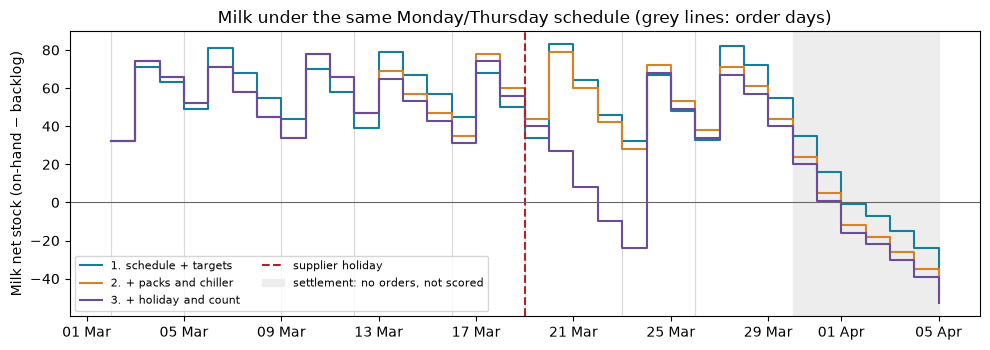

In [11]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 3.6))
for (name, result), color in zip(runs.items(), ["#167d9a", "#d58228", "#6b4c9a"]):
    milk = result.to_event_frame().query("unique_id == 'milk'")
    net = milk["ending_on_hand"] - milk["backorders_end"]
    ax.step(milk["date"], net, where="post", label=name, color=color)
for p in decision_periods:
    ax.axvline(origin + pd.Timedelta(days=p + 1), color="0.85", linewidth=0.8, zorder=0)
ax.axvline(holiday, color="#b22222", linestyle="--", label="supplier holiday")
settlement_start = origin + pd.Timedelta(days=warmup + scoring + 1)
ax.axvspan(settlement_start, demand["date"].max(), color="0.93", zorder=-1,
           label="settlement: no orders, not scored")
ax.axhline(0, color="0.4", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set(ylabel="Milk net stock (on-hand − backlog)",
       title="Milk under the same Monday/Thursday schedule (grey lines: order days)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Takeaway

- **Schedules** decide *when*. Any deterministic rule works if it can name the
  next opportunity; irregular gaps mean irregular protection windows.
- **Constraints** turn requests into orders the operation can accept, with an
  audit trail. Write your own when the built-ins' composition is too strict.
- **Scheduled callbacks** inject known calendar events without custom code.

The engine keeps the accounting, timing, and validation in every case. None of
these results is a forecast accuracy claim. The demand rates are known, and the
costs of holidays or shrink are not evaluated here.